In [12]:
import json
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

In [13]:
with open('/content/train_spider.json') as f:
  spider_data = json.load(f)

In [14]:
queries = [item['query'] for item in spider_data]
print(f"total sql queries loaded: {len(queries)}")
print(f"example query: {queries[0]}")

total sql queries loaded: 7000
example query: SELECT count(*) FROM head WHERE age  >  56


In [15]:
custom_filters = '"#$%&+-./:;<>?@[\\]^_`{|}~\t\n'
tok = Tokenizer(filters = custom_filters, lower = True)
tok.fit_on_texts(queries)
total_words = len(tok.word_index) + 1
print(f"total words: {total_words}")

total words: 3004


In [16]:
input_sequences = []
for line in queries:
  token_list = tok.texts_to_sequences([line])[0]
  for i in range(1, len(token_list)):
    n_gram_sequence = token_list[:i+1]
    input_sequences.append(n_gram_sequence)

print(f"Total N-gram sequences: {len(input_sequences)}")
print(f"example N-gram sequence: {input_sequences[0]}")

Total N-gram sequences: 136105
example N-gram sequence: [4, 15]


In [17]:
max_seq_len = max([len(x) for x in input_sequences])
input_sequences = np.array(pad_sequences(input_sequences, maxlen = max_seq_len, padding = 'pre'))

In [18]:
X, labels = input_sequences[:, :-1], input_sequences[:, -1]

In [19]:
print("--- Shapes Ready for Model Training ---")
print(f"Max Sequence Length: {max_seq_len}")
print(f"Input Features Shape (X): {X.shape}")
print(f"Target Labels Shape: {labels.shape}")

--- Shapes Ready for Model Training ---
Max Sequence Length: 127
Input Features Shape (X): (136105, 126)
Target Labels Shape: (136105,)


In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional

In [21]:
model = Sequential()
model.add(Embedding(input_dim = total_words, output_dim = 100, input_length = max_seq_len-1))
model.add(Bidirectional(LSTM(150)))
model.add(Dense(total_words, activation='softmax'))
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
print(model.summary())

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [22]:
from tensorflow.keras.callbacks import EarlyStopping
es = EarlyStopping(monitor = 'loss', patience = 5, restore_best_weights=True)

In [23]:
history = model.fit(X, labels, epochs = 100, batch_size=64, callbacks = [es], verbose=1)

Epoch 1/100
2127/2127 ━━━━━━━━━━━━━━━━━━━━ 43s 17ms/step - accuracy: 0.4379 - loss: 3.1785
Epoch 2/100
2127/2127 ━━━━━━━━━━━━━━━━━━━━ 38s 18ms/step - accuracy: 0.5331 - loss: 2.3377
Epoch 3/100
2127/2127 ━━━━━━━━━━━━━━━━━━━━ 38s 18ms/step - accuracy: 0.5777 - loss: 1.9859
Epoch 4/100
2127/2127 ━━━━━━━━━━━━━━━━━━━━ 38s 18ms/step - accuracy: 0.6247 - loss: 1.6875
Epoch 5/100
2127/2127 ━━━━━━━━━━━━━━━━━━━━ 38s 18ms/step - accuracy: 0.6676 - loss: 1.4502
Epoch 6/100
2127/2127 ━━━━━━━━━━━━━━━━━━━━ 38s 18ms/step - accuracy: 0.6999 - loss: 1.2730
Epoch 7/100
2127/2127 ━━━━━━━━━━━━━━━━━━━━ 38s 18ms/step - accuracy: 0.7247 - loss: 1.1414
Epoch 8/100
2127/2127 ━━━━━━━━━━━━━━━━━━━━ 38s 18ms/step - accuracy: 0.7449 - loss: 1.0419
Epoch 9/100
2127/2127 ━━━━━━━━━━━━━━━━━━━━ 41s 18ms/step - accuracy: 0.7636 - loss: 0.9599
Epoch 10/100
2127/2127 ━━━━━━━━━━━━━━━━━━━━ 38s 18ms/step - accuracy: 0.7782 - loss: 0.8931
Epoch 11/100
2127/2127 ━━━━━━━━━━━━━━━━━━━━ 38s 18ms/step - accuracy: 0.7897 - loss: 0.84

In [24]:
final_loss = history.history['loss'][-1]
final_acc = history.history['accuracy'][-1]

print("FINAL Bi-LSTM METRICS")
print(f"Final Loss:{final_loss:.4f}")
print(f"Final Accuracy: {final_acc * 100:.2f}%")

FINAL Bi-LSTM METRICS
Final Loss:0.4658
Final Accuracy: 87.91%


FINAL TRAINING METRICS
Final Loss (Categorical CE): 0.4658
Final Accuracy:              87.91%
Perplexity:                  1.59


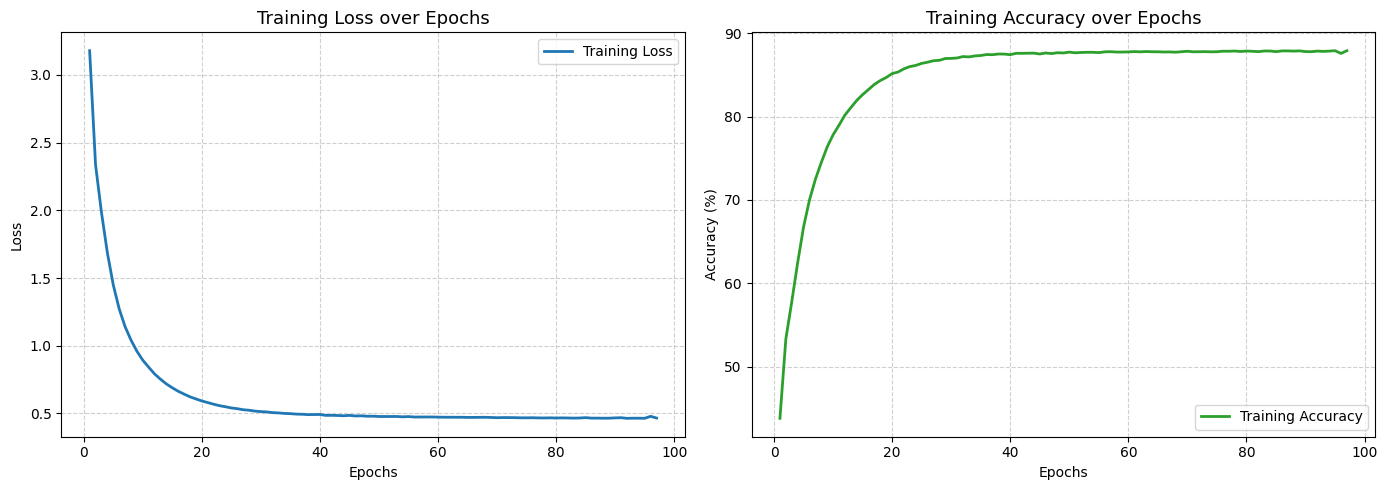

In [25]:
import matplotlib.pyplot as plt
import numpy as np

final_loss = history.history['loss'][-1]
final_acc = history.history['accuracy'][-1]
perplexity = np.exp(final_loss)

print("FINAL TRAINING METRICS")
print("=" * 40)
print(f"Final Loss (Categorical CE): {final_loss:.4f}")
print(f"Final Accuracy:              {final_acc * 100:.2f}%")
print(f"Perplexity:                  {perplexity:.2f}")  # ow surprised or confused a model is when predicting the next word in a sequence.

epochs_range = range(1, len(history.history['loss']) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history.history['loss'], label='Training Loss', color='#1f77b4', linewidth=2)
plt.title('Training Loss over Epochs', fontsize=13)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, [acc * 100 for acc in history.history['accuracy']], label='Training Accuracy', color='#2ca02c', linewidth=2)
plt.title('Training Accuracy over Epochs', fontsize=13)
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

In [26]:
import pickle
from google.colab import files

model.save('sql_bi_lstm_model.h5')

with open('tok.pkl', 'wb') as handle:
    pickle.dump(tok, handle, protocol=pickle.HIGHEST_PROTOCOL)

with open('max_len.pkl', 'wb') as handle:
    pickle.dump(max_seq_len, handle, protocol=pickle.HIGHEST_PROTOCOL)